In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## PODSTAWOWE INFORMACJE O ZBIORZE:

In [6]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [5]:
print('--- Próbka danych ---')
display(df.head()) # w jupyter używamy display() dla ładniejszych tabelek

print('\n--- Informacje o zbiorze danych ---')
df.info()

print('\n--- Sprawdzenie braków danych ---')
display(df.isnull().sum())

print('\n--- Podstawowe statystyki opisowe ---')
display(df.describe().T)

--- Próbka danych ---


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1



--- Informacje o zbiorze danych ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
mem

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


--- Podstawowe statystyki opisowe ---


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0



--- Analiza zdarzenia (DEATH_EVENT) ---
Liczba zgonów (zdarzenie = 1): 96 (32.1%)
Liczba obserwacji cenzurowanych (zdarzenie = 0): 203 (67.9%)


C:\Users\matma\AppData\Local\Temp\ipykernel_30752\2311144628.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DEATH_EVENT', palette='viridis')


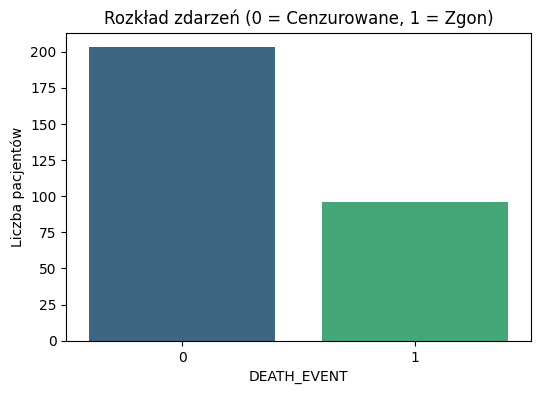

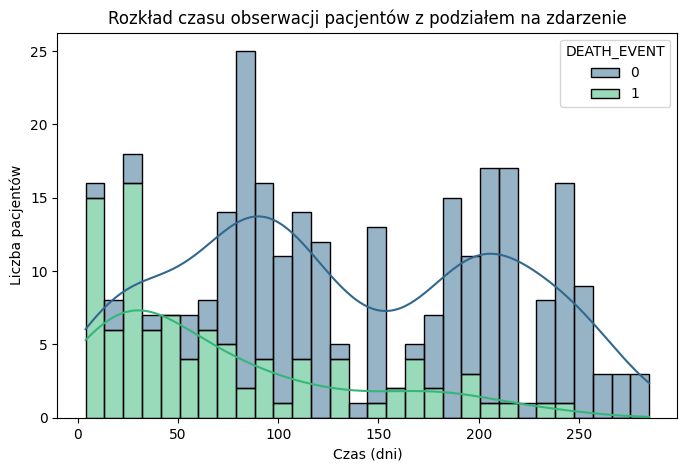

In [4]:
print('\n--- Analiza zdarzenia (DEATH_EVENT) ---')
event_counts = df['DEATH_EVENT'].value_counts()
event_percentages = df['DEATH_EVENT'].value_counts(normalize=True) * 100

print(f'Liczba zgonów (zdarzenie = 1): {event_counts[1]} ({event_percentages[1]:.1f}%)')
print(f'Liczba obserwacji cenzurowanych (zdarzenie = 0): {event_counts[0]} ({event_percentages[0]:.1f}%)')

## Wizualizacja rozkładu zmiennej DEATH_EVENT
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DEATH_EVENT', palette='viridis')
plt.title('Rozkład zdarzeń (0 = Cenzurowane, 1 = Zgon)')
plt.ylabel('Liczba pacjentów')
plt.show()

## Wizualizacja rozkładu zmiennej DEATH_EVENT w czasie
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='time', bins=30, kde=True, hue='DEATH_EVENT', palette='viridis', multiple='stack')
plt.title('Rozkład czasu obserwacji pacjentów z podziałem na zdarzenie')
plt.xlabel('Czas (dni)')
plt.ylabel('Liczba pacjentów')
plt.show()